# In this notebook, I'll be running the RC KAN for the Feynman dataset, as per https://arxiv.org/pdf/2404.19756v4#page=3.67

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
torch.set_default_device('cuda')
tpi = torch.tensor(torch.pi)

In [2]:
# Redefine instead as a network of KAN nodes
class PhyKAN(nn.Module):
    def __init__(self, KANshape, filters_per_unit):
        super().__init__()
        # Find number of layers
        self.Nlayers = len(KANshape)-1
        self.KANshape = KANshape
        # Create parameters for each layer
        self.filter_params = []
        for i in range(self.Nlayers):
            layer_params = 4*(torch.rand((KANshape[i], KANshape[i+1], filters_per_unit, 3))-0.5)
            layer_params.requires_grad=True
            self.filter_params.append(layer_params)
        self.optim = torch.optim.Adam(params=self.filter_params, lr=1e-3)
        self.lossfn = nn.MSELoss()
        
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, Xin, params):
        # Bound parameters
        params=params.sigmoid()
        # Normalise input of 0-1 to frequencies of 100 Hz-100 kHz
        freq = 10**(2+3*Xin)
        freq = torch.tile(freq, (len(params), 1)).T
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 5X
        gain = 10*(params[:, 0]-0.5)
        # Set cutoff frequencies between 10 Hz and 1 MHz
        fc_low = 10+(10**(6*params[:, 1]))
        fc_high = 10+(10**(6*params[:, 2]))
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        Hout = gain[:]*torch.abs((2j*torch.pi*freq*RC_low[:]/(1+2j*torch.pi*freq*RC_low[:]))*(1/(1+2j*torch.pi*freq*RC_high[:])))
        return Hout.sum(dim=1)
    
    def forward(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        inputs[0][:, :] = Xin
        # Pass through model
        for layer in range(self.Nlayers):
            for inp in range(self.KANshape[layer]):
                for node in range(self.KANshape[layer+1]):
                    outputs[layer][:, node] += self.band_pass(inputs[layer][:, inp], self.filter_params[layer][inp, node, :])      
            if layer < self.Nlayers-1:
                inputs[layer+1][:, :] = outputs[layer][:, :]
        return outputs[-1]
    
    def train(self, Xin, Yin):
        self.optim.zero_grad()
        pred = self.forward(Xin)
        loss = self.lossfn(pred, Yin)
        loss.backward()
        self.optim.step()
        return(loss.item())

In [3]:
class PhyKAN_basis(nn.Module):
    def __init__(self, KANshape, filters_per_unit):
        super().__init__()
        self.Nin = KANshape[0]
        self.Nout = KANshape[-1]
        self.Nlayers = len(KANshape)-1
        self.KANshape = KANshape
        self.filter_params = []
        self.basis_params = []
        print(KANshape)
        for i in range(self.Nlayers):
            layer_params = 4*(torch.rand((KANshape[i], KANshape[i+1], filters_per_unit, 3))-0.5)
            layer_params.requires_grad=True
            basis_params = 2*np.sqrt(6)*((torch.rand((KANshape[i], KANshape[i+1]))-0.5))/(np.sqrt(KANshape[i]+KANshape[i+1]))
            basis_params.requires_grad=True
            self.filter_params.append(layer_params)
            self.basis_params.append(basis_params)
        self.optim = torch.optim.Adam([{ 'params': self.filter_params+self.basis_params, 'lr':1e-3 }])
        self.lossfn = nn.MSELoss()
        self.basis_fn = nn.SiLU()
        
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, Xin, params):
        # Bound parameters
        params=params.sigmoid()
        # Normalise input of 0-1 to frequencies of 100 Hz-100 kHz
        freq = 10**(2+3*Xin)
        freq = torch.tile(freq, (len(params), 1)).T
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 5X
        gain = 10*(params[:, 0]-0.5)
        # Set cutoff frequencies between 10 Hz and 1 MHz
        fc_low = 10+(10**(6*params[:, 1]))
        fc_high = 10+(10**(6*params[:, 2]))
        RC_low = (2*torch.pi*fc_low)**-1
        RC_high = (2*torch.pi*fc_high)**-1
        Hout = gain[:]*torch.abs((2j*torch.pi*freq*RC_low[:]/(1+2j*torch.pi*freq*RC_low[:]))*(1/(1+2j*torch.pi*freq*RC_high[:])))
        return Hout.sum(dim=1)
    
    
    def forward(self, Xin):
        batch_size = len(Xin)
        # Initialise inputs to and outputs from each layer
        inputs = []
        outputs = []
        for i in range(self.Nlayers):
            inputs.append(torch.zeros((batch_size, self.KANshape[i])))
            outputs.append(torch.zeros((batch_size, self.KANshape[i+1])))
        inputs[0][:, :] = Xin

        # Pass through model
        for layer in range(self.Nlayers):
            for inp in range(self.KANshape[layer]):
                for node in range(self.KANshape[layer+1]):
                    outputs[layer][:, node] += self.band_pass(inputs[layer][:, inp], self.filter_params[layer][inp, node, :]) + (self.basis_params[layer][inp, node]*self.basis_fn(inputs[layer][:, inp]))
            if layer < self.Nlayers-1:
                inputs[layer+1][:, :] = outputs[layer][:, :]
        return outputs[-1]
    
    def train(self, Xin, Yin):
        self.optim.zero_grad()
        pred = self.forward(Xin)
        loss = self.lossfn(pred, Yin)
        loss.backward()
        self.optim.step()
        return(loss.item())

In [4]:
# Equation 1: 
f = lambda x: torch.exp(-x[:,[0]]**2/(2*x[:,[1]]**2))/torch.sqrt(2*torch.pi*x[:,[1]]**2)
model1 = PhyKAN_basis([2, 3, 3, 1], 8)

for i in range(100000):
    Xs = torch.rand(1000, 2)
    Xs_f = torch.zeros_like(Xs)
    Xs_f[:,0]=(Xs[:,0]-0.5)*2
    Xs_f[:,1]=0.5+(Xs[:,1]*1.5)
    Ys = f(Xs_f)
    loss = model1.train(Xs, Ys)
    if i%10000 == 0:
        print(loss)

[2, 3, 3, 1]
2.8937172889709473
0.0002868465380743146
3.6292090044298675e-06
1.1608073009483633e-06
1.4919811519575887e-06
6.935196097401786e-07
2.1348553218558664e-06
5.205377533457067e-07
5.361777084544883e-07
7.540077717749227e-07


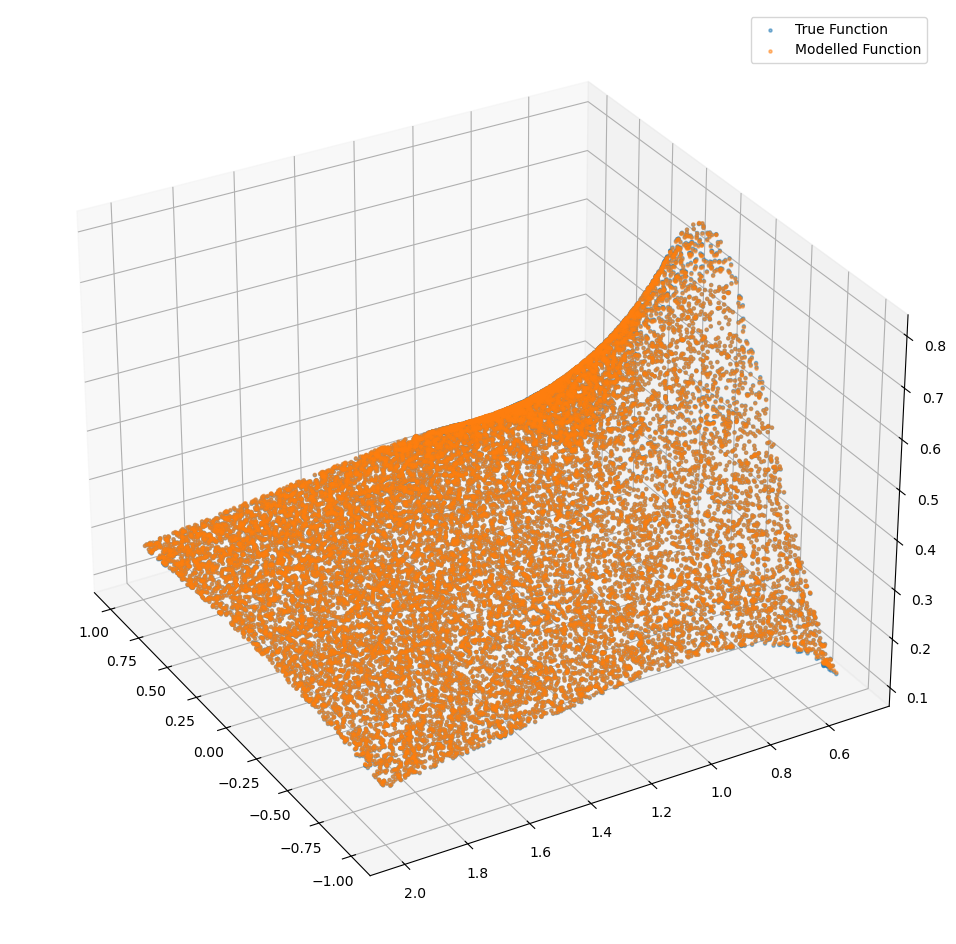

In [5]:
# Visualise the results in 3D:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

Xs = torch.rand(20000, 2)
Xs_f = torch.zeros_like(Xs)
Xs_f[:,0]=(Xs[:,0]-0.5)*2
Xs_f[:,1]=0.5+(Xs[:,1]*1.5)
y_true = f(Xs_f)
y_pred = model1.forward(Xs)

y_true = y_true.cpu().numpy()
y_pred = y_pred.cpu().detach().numpy()

ax.scatter(Xs_f[:, 0].cpu().numpy(), Xs_f[:, 1].cpu().numpy(), y_true, label='True Function', alpha=0.5, s=5)
ax.scatter(Xs_f[:, 0].cpu().numpy(), Xs_f[:, 1].cpu().numpy(), y_pred, label='Modelled Function', alpha=0.5, s=5)
ax.view_init(elev=30, azim=150)
plt.legend()
plt.show()

In [6]:
# Equation 2:
f = lambda x: torch.exp(-((x[:,[0]]-x[:,[1]])**2/(2*x[:,[2]]**2)))/(torch.sqrt(2*torch.pi*x[:,[1]]**2))
model2 = PhyKAN_basis([3, 2, 2, 1], 8)

for i in range(100000):
    Xs = torch.rand(10000, 2)+0.05
    Ys = f(Xs)
    loss = model2.train(Xs, Ys)
    if i%10000 == 0:
        print(loss)

# Visualise the results in 3D:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')

xs = torch.rand(1000, 2)+0.1
y_true = f(xs)
y_pred = model2.forward(xs)

xs = xs.cpu().numpy()
y_true = y_true.cpu().numpy()
y_pred = y_pred.cpu().detach().numpy()

ax.scatter(xs[:, 0], xs[:, 1], y_true, label='True Function', alpha=0.5, s=5)
ax.scatter(xs[:, 0], xs[:, 1], y_pred, label='Modelled Function', alpha=0.5, s=5)
plt.legend()
plt.show()

[3, 2, 2, 1]


/opt/conda/conda-bld/pytorch_1720538616722/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [6,0,0], thread: [64,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1720538616722/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [6,0,0], thread: [65,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1720538616722/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [6,0,0], thread: [66,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1720538616722/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: [6,0,0], thread: [67,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/opt/conda/conda-bld/pytorch_1720538616722/work/aten/src/ATen/native/cuda/IndexKernel.cu:92: operator(): block: 

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
